1. Import Library
2. Mount Drive
3. Load Dataset
4. EDA
   - Distribusi kelas
   - Visualisasi sampel
   - Histogram RGB

5. PREPROCESSING
   - BGR → RGB
   - Segmentasi nucleus (HSV)
   - Morphology Opening & Closing
   - Bounding Box
   - ROI Cropping
   - Resize 224×224
   - Simpan hasil preprocessing

6. Split Dataset
   - Train 70%
   - Validation 15%
   - Test 15%

7. Ekstraksi Fitur Morfologi
   - Area
   - Perimeter
   - Circularity
   - Solidity
   - Extent
   - Eccentricity
   - Major Axis
   - Minor Axis

8. SVM

9. CNN

11. Perbandingan Model

In [ ]:
import os
import cv2
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from glob import glob

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from skimage.measure import label, regionprops

import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
dataset_path = "/content/drive/MyDrive/Blood Cell"

kelas = sorted(os.listdir(dataset_path))

print(kelas)

['basophil', 'erythroblast', 'monocyte', 'myeloblast', 'seg_neutrophil']


#EDA

Distribusi Kelas

In [ ]:
jumlah_data = []

for k in kelas:
    folder = os.path.join(dataset_path, k)
    jumlah = len(os.listdir(folder))

    jumlah_data.append(jumlah)

    print(f"{k}: {jumlah}")

basophil: 1000
erythroblast: 1000
monocyte: 1000
myeloblast: 1000
seg_neutrophil: 1000


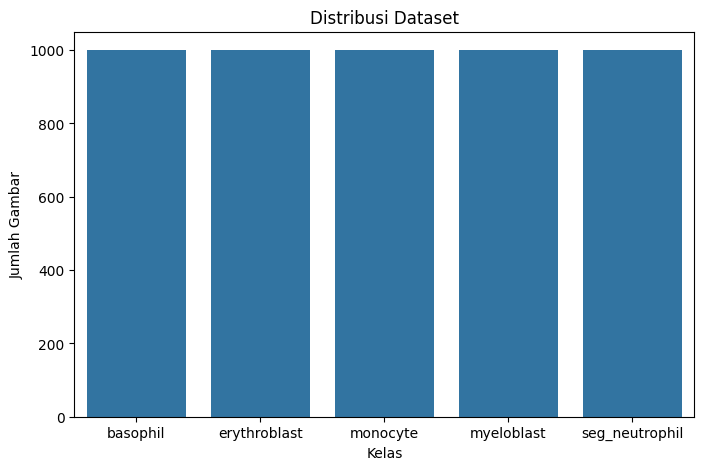

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=kelas,
    y=jumlah_data
)

plt.title("Distribusi Dataset")
plt.xlabel("Kelas")
plt.ylabel("Jumlah Gambar")

plt.show()

Sample

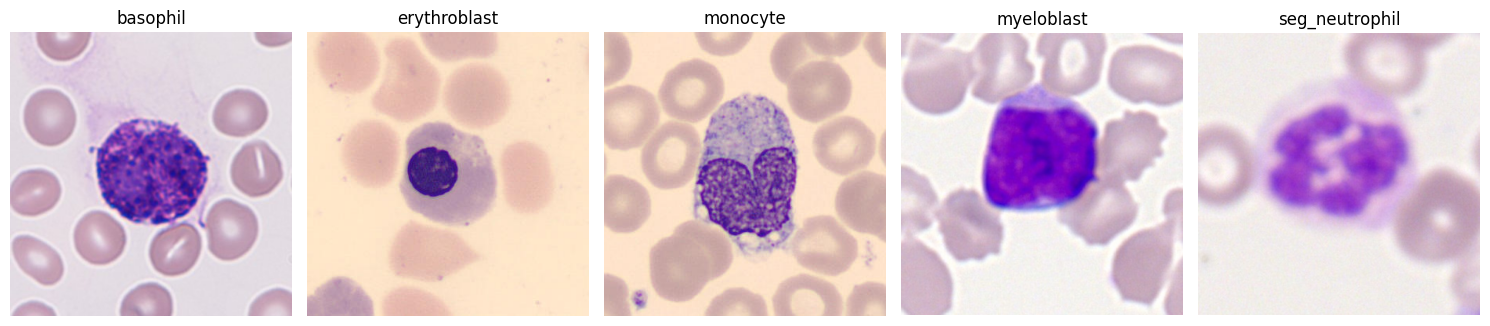

In [ ]:
sample_images = {}

plt.figure(figsize=(15,5))

for i, k in enumerate(kelas):

    folder = os.path.join(dataset_path, k)

    file_img = random.choice(os.listdir(folder))

    path_img = os.path.join(folder, file_img)

    img = cv2.imread(path_img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    sample_images[k] = img

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(k)
    plt.axis("off")

plt.tight_layout()
plt.show()

Ukuran Citra

In [ ]:
for k, img in sample_images.items():
    print(k, "->", img.shape)

basophil -> (369, 366, 3)
erythroblast -> (363, 360, 3)
monocyte -> (363, 360, 3)
myeloblast -> (400, 400, 3)
seg_neutrophil -> (400, 400, 3)


Histogram RGB

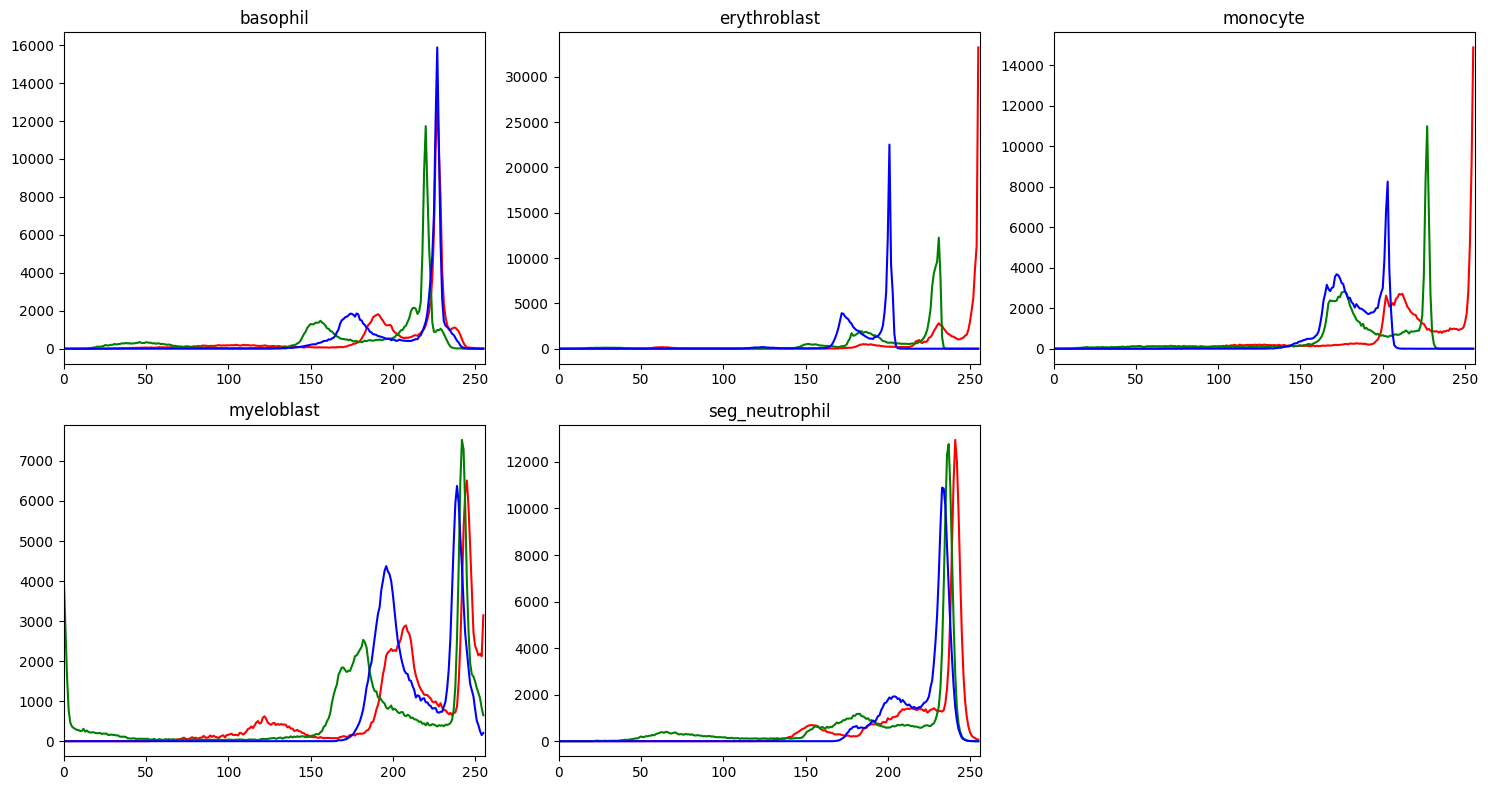

In [ ]:
plt.figure(figsize=(15,8))

for i, (k, img) in enumerate(sample_images.items()):

    plt.subplot(2,3,i+1)

    colors = ("red","green","blue")

    for j,col in enumerate(colors):
        hist = cv2.calcHist([img],[j],None,[256],[0,256])
        plt.plot(hist,color=col)

    plt.title(k)
    plt.xlim([0,256])

plt.tight_layout()
plt.show()

#PREPROCESSING

BGR ke RGB

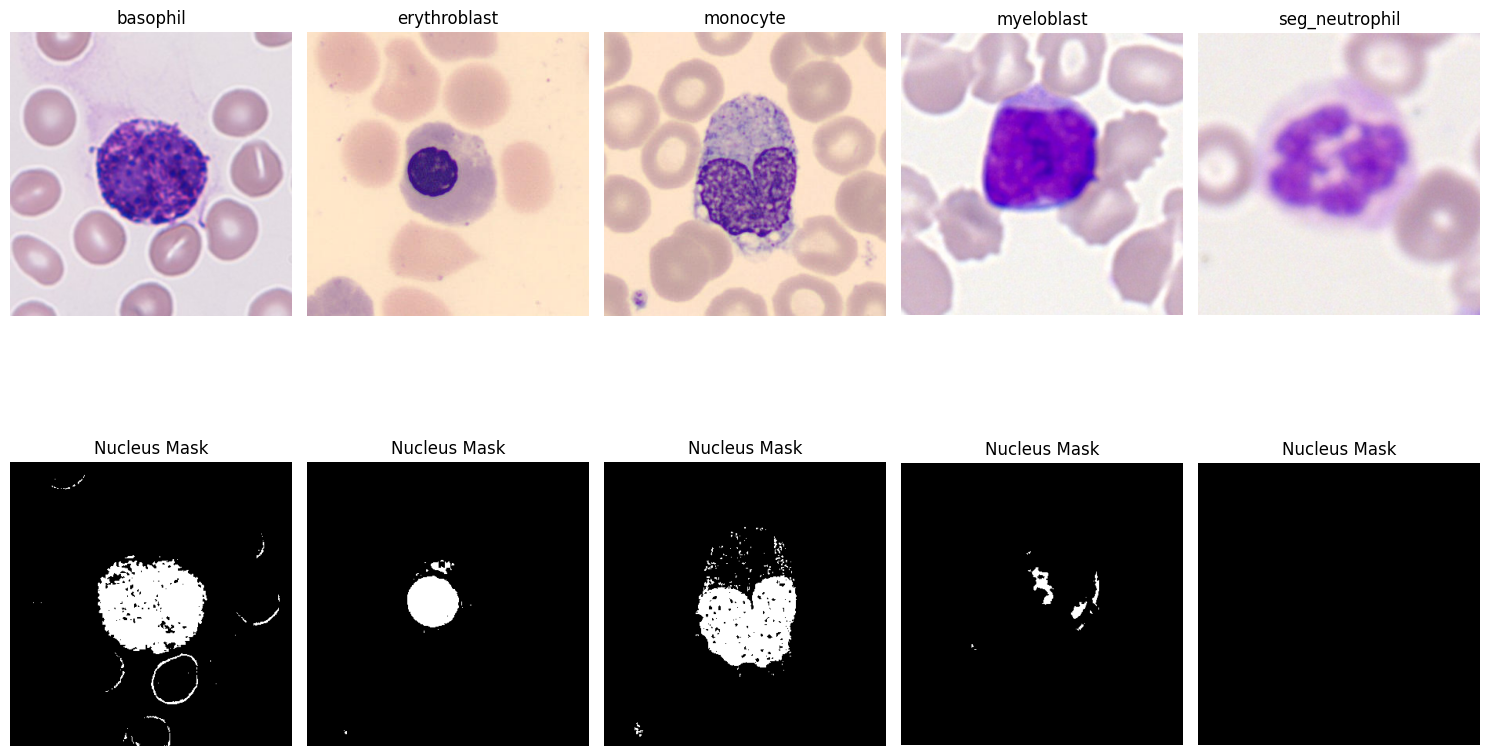

In [ ]:
plt.figure(figsize=(15,10))

for i,(k,img) in enumerate(sample_images.items()):

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    lower = np.array([110,50,20])
    upper = np.array([170,255,180])

    mask = cv2.inRange(hsv, lower, upper)

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(k)
    plt.axis("off")

    plt.subplot(2,5,i+6)
    plt.imshow(mask,cmap="gray")
    plt.title("Nucleus Mask")
    plt.axis("off")

plt.tight_layout()
plt.show()

RGB ke HSV

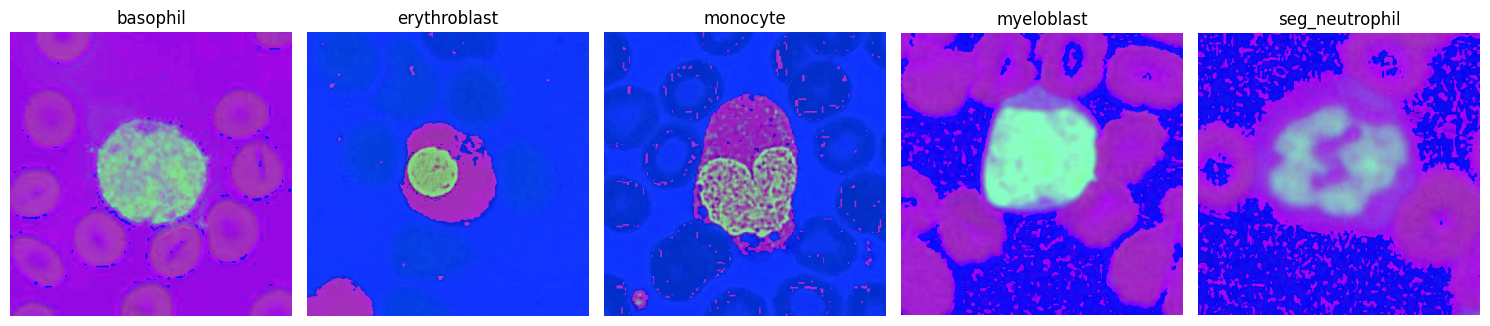

In [ ]:
plt.figure(figsize=(15,5))

for i,(k,img) in enumerate(sample_images.items()):

    hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

    plt.subplot(1,5,i+1)

    plt.imshow(hsv)

    plt.title(k)

    plt.axis("off")

plt.tight_layout()
plt.show()

Segmentasi Nucleus

In [ ]:
def deteksi_nucleus(img):

    hsv = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2HSV
    )

    lower = np.array([110,40,20])
    upper = np.array([170,255,255])

    mask = cv2.inRange(
        hsv,
        lower,
        upper
    )

    kernel = np.ones(
        (5,5),
        np.uint8
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_OPEN,
        kernel
    )

    mask = cv2.morphologyEx(
        mask,
        cv2.MORPH_CLOSE,
        kernel
    )

    contours, _ = cv2.findContours(
        mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    if len(contours) == 0:
        return mask, None

    contour = max(
        contours,
        key=cv2.contourArea
    )

    x,y,w,h = cv2.boundingRect(
        contour
    )

    return mask, (x,y,w,h)

Bounding Box

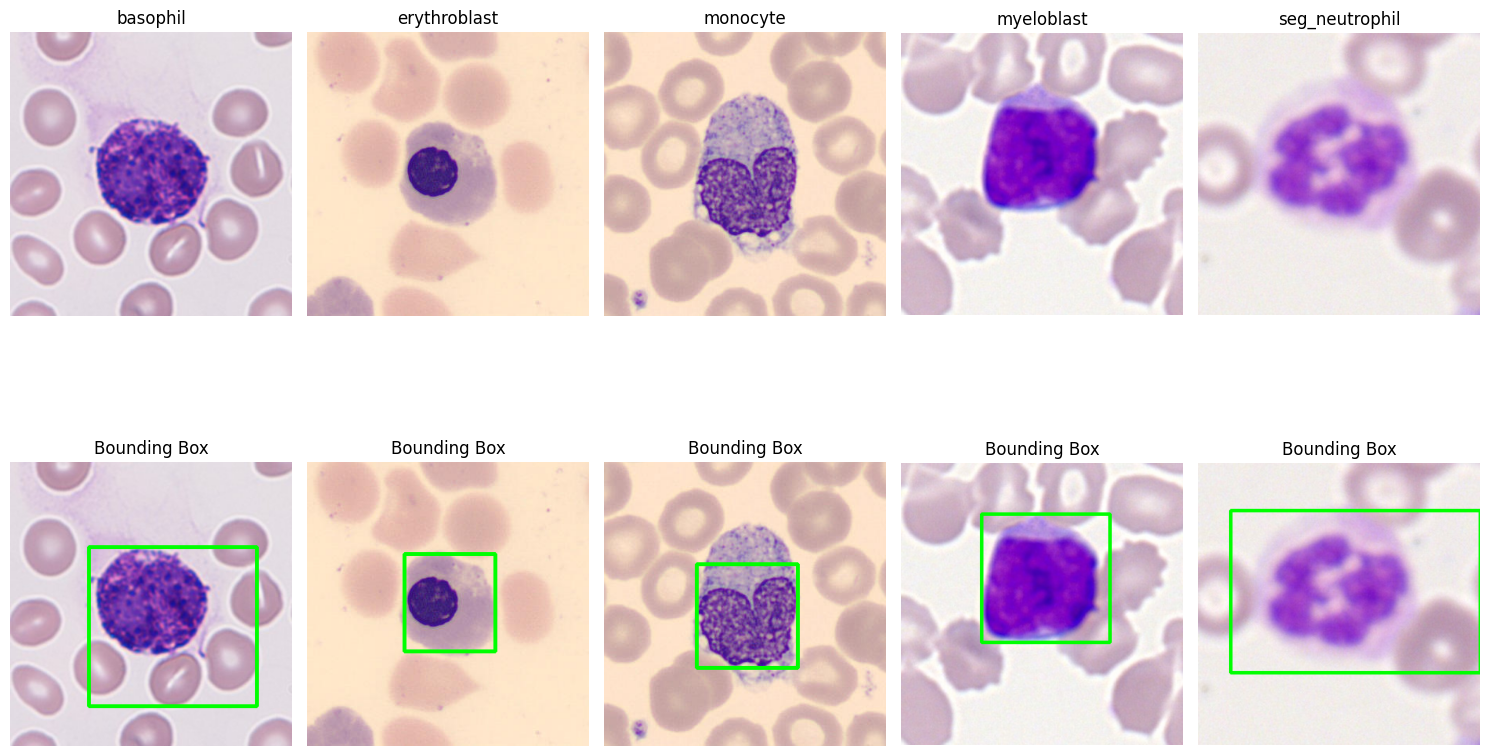

In [ ]:
plt.figure(figsize=(15,10))

for i,(k,img) in enumerate(sample_images.items()):

    mask, bbox = deteksi_nucleus(img)

    hasil = img.copy()

    if bbox is not None:

        x,y,w,h = bbox

        cv2.rectangle(
            hasil,
            (x,y),
            (x+w,y+h),
            (0,255,0),
            3
        )

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.title(k)
    plt.axis("off")

    plt.subplot(2,5,i+6)
    plt.imshow(hasil)
    plt.title("Bounding Box")
    plt.axis("off")

plt.tight_layout()
plt.show()

Crop ROI

In [ ]:
def crop_nucleus(
    img,
    bbox,
    padding=15
):

    x,y,w,h = bbox

    x = max(0,x-padding)
    y = max(0,y-padding)

    w = min(
        img.shape[1]-x,
        w+2*padding
    )

    h = min(
        img.shape[0]-y,
        h+2*padding
    )

    roi = img[y:y+h,x:x+w]

    return roi

In [ ]:
output_path = "/content/drive/MyDrive/Blood_Cell_Preprocessed"

In [ ]:
# from tqdm import tqdm

# berhasil = 0
# gagal = 0

# for k in kelas:

#     input_folder = os.path.join(dataset_path, k)
#     output_folder = os.path.join(output_path, k)

#     files = os.listdir(input_folder)

#     for nama_file in tqdm(files, desc=k):

#         path_img = os.path.join(input_folder, nama_file)

#         img = cv2.imread(path_img)

#         if img is None:
#             gagal += 1
#             continue

#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#         mask, bbox = deteksi_nucleus(img)

#         if bbox is None:
#             gagal += 1
#             continue

#         roi = crop_nucleus(img, bbox)

#         roi = cv2.resize(roi, (224,224))

#         roi = cv2.cvtColor(roi, cv2.COLOR_RGB2BGR)

#         cv2.imwrite(
#             os.path.join(output_folder, nama_file),
#             roi
#         )

#         berhasil += 1

# print(f"Berhasil : {berhasil}")
# print(f"Gagal    : {gagal}")

Visualisasi Hasil Preprocessing

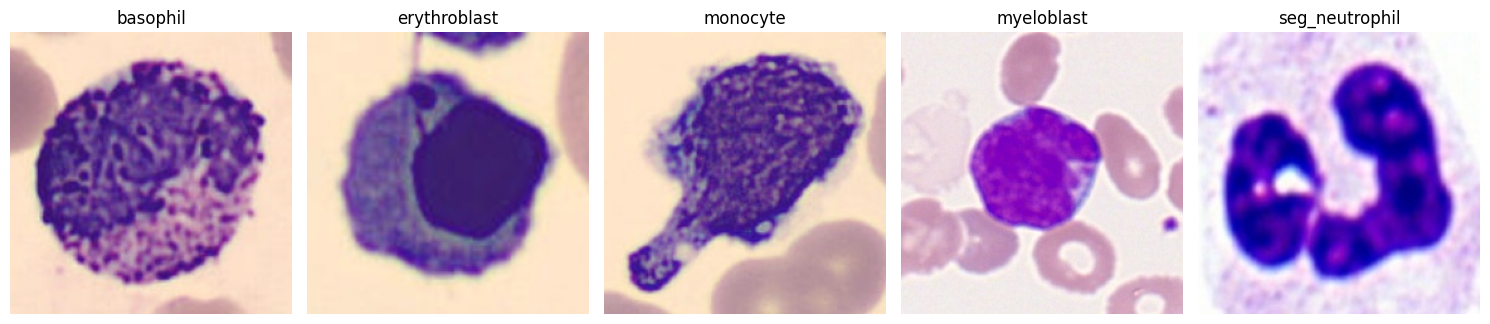

In [ ]:
plt.figure(figsize=(15,5))

for i,k in enumerate(kelas):

    folder = os.path.join(output_path, k)

    file_img = random.choice(os.listdir(folder))

    img = cv2.imread(os.path.join(folder, file_img))

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)

    plt.imshow(img)

    plt.title(k)

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# for k in kelas:

#     folder = os.path.join(output_path, k)

#     print(
#         k,
#         len(os.listdir(folder))
#     )

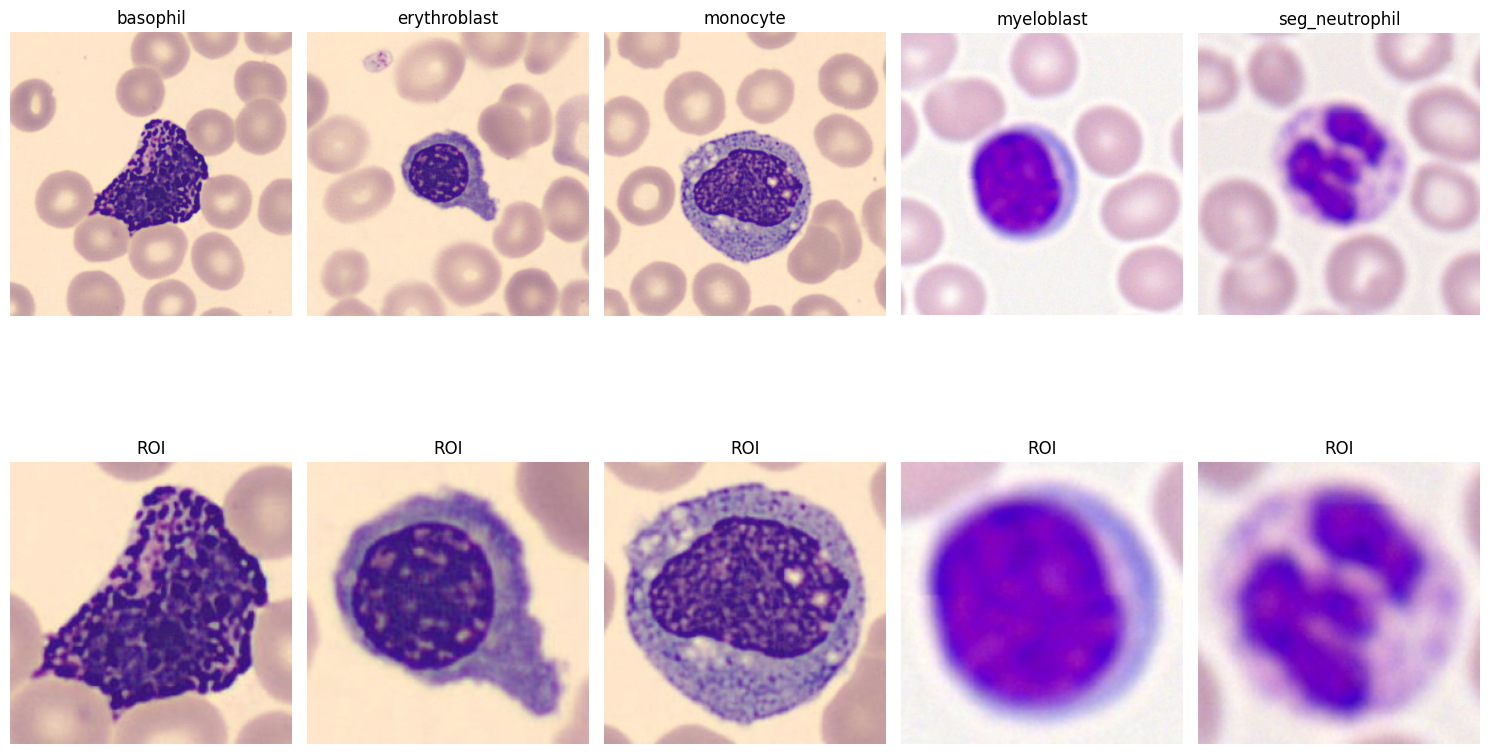

In [ ]:
plt.figure(figsize=(15,10))

for i,k in enumerate(kelas):

    folder_asli = os.path.join(dataset_path, k)

    folder_crop = os.path.join(output_path, k)

    nama = random.choice(os.listdir(folder_crop))

    asli = cv2.imread(
        os.path.join(folder_asli, nama)
    )

    asli = cv2.cvtColor(
        asli,
        cv2.COLOR_BGR2RGB
    )

    crop = cv2.imread(
        os.path.join(folder_crop, nama)
    )

    crop = cv2.cvtColor(
        crop,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,5,i+1)
    plt.imshow(asli)
    plt.title(k)
    plt.axis("off")

    plt.subplot(2,5,i+6)
    plt.imshow(crop)
    plt.title("ROI")
    plt.axis("off")

plt.tight_layout()
plt.show()

Split Dataset

In [ ]:
from sklearn.model_selection import train_test_split
import shutil

In [ ]:
split_path = "/content/drive/MyDrive/Blood_Cell_Split"

In [ ]:
# for k in kelas:

#     source_folder = os.path.join(
#         output_path,
#         k
#     )

#     files = os.listdir(source_folder)

#     train_files, temp_files = train_test_split(
#         files,
#         test_size=0.30,
#         random_state=42
#     )

#     val_files, test_files = train_test_split(
#         temp_files,
#         test_size=0.50,
#         random_state=42
#     )

#     for f in train_files:

#         shutil.copy(
#             os.path.join(source_folder,f),
#             os.path.join(
#                 split_path,
#                 "train",
#                 k,
#                 f
#             )
#         )

#     for f in val_files:

#         shutil.copy(
#             os.path.join(source_folder,f),
#             os.path.join(
#                 split_path,
#                 "val",
#                 k,
#                 f
#             )
#         )

#     for f in test_files:

#         shutil.copy(
#             os.path.join(source_folder,f),
#             os.path.join(
#                 split_path,
#                 "test",
#                 k,
#                 f
#             )
#         )

Hasil Split

In [ ]:
for subset in ["train","val","test"]:

    print(f"\n{subset.upper()}")

    total = 0

    for k in kelas:

        n = len(
            os.listdir(
                os.path.join(
                    split_path,
                    subset,
                    k
                )
            )
        )

        total += n

        print(k, n)

    print("Total :", total)


TRAIN
basophil 868
erythroblast 848
monocyte 859
myeloblast 875
seg_neutrophil 853
Total : 4303

VAL
basophil 251
erythroblast 259
monocyte 267
myeloblast 270
seg_neutrophil 251
Total : 1298

TEST
basophil 272
erythroblast 256
monocyte 253
myeloblast 263
seg_neutrophil 264
Total : 1308


Ekstraksi Fitur Training

In [ ]:
from skimage.measure import label, regionprops

def ekstrak_fitur(img):

    gray = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2GRAY
    )

    _, thresh = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
    )

    label_img = label(thresh)

    props = regionprops(label_img)

    if len(props) == 0:
        return None

    obj = max(
        props,
        key=lambda x: x.area
    )

    area = obj.area
    perimeter = obj.perimeter
    eccentricity = obj.eccentricity
    solidity = obj.solidity
    extent = obj.extent

    major_axis = obj.major_axis_length
    minor_axis = obj.minor_axis_length

    circularity = (
        4*np.pi*area/(perimeter**2)
        if perimeter > 0 else 0
    )

    return [
        area,
        perimeter,
        circularity,
        solidity,
        extent,
        eccentricity,
        major_axis,
        minor_axis
    ]

In [ ]:
train_data = []

train_folder = os.path.join(
    split_path,
    "train"
)

for k in kelas:

    folder_kelas = os.path.join(
        train_folder,
        k
    )

    for file_img in tqdm(
        os.listdir(folder_kelas),
        desc=f"Train {k}"
    ):

        path_img = os.path.join(
            folder_kelas,
            file_img
        )

        img = cv2.imread(path_img)

        if img is None:
            continue

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        fitur = ekstrak_fitur(img)

        if fitur is None:
            continue

        fitur.append(k)

        train_data.append(fitur)

Train seg_neutrophil: 100%|██████████| 853/853 [00:27<00:00, 30.80it/s]


In [ ]:
kolom = [
    "area",
    "perimeter",
    "circularity",
    "solidity",
    "extent",
    "eccentricity",
    "major_axis",
    "minor_axis",
    "label"
]

df_train = pd.DataFrame(
    train_data,
    columns=kolom
)

df_train.head()

,area,perimeter,circularity,solidity,extent,eccentricity,major_axis,minor_axis,label
0,23572.0,1665.628642,0.106770,0.915844,0.719536,0.366331,183.526582,170.768672,basophil
1,21277.0,1714.481456,0.090961,0.875237,0.632003,0.461810,179.013260,158.780940,basophil
2,21130.0,2121.720092,0.058984,0.835772,0.627562,0.611767,192.399901,152.195621,basophil
3,16977.0,1091.507755,0.179068,0.797342,0.521567,0.556342,164.628306,136.798409,basophil
4,24095.0,2026.394190,0.073738,0.904739,0.711712,0.447531,188.589975,168.650085,basophil


In [ ]:
print(df_train.shape)

df_train["label"].value_counts()

(4303, 9)


,count
label,
myeloblast,875
basophil,868
monocyte,859
seg_neutrophil,853
erythroblast,848


Ekstraksi Fitur Testing

In [ ]:
test_data = []

test_folder = os.path.join(
    split_path,
    "test"
)

for k in kelas:

    folder_kelas = os.path.join(
        test_folder,
        k
    )

    for file_img in tqdm(
        os.listdir(folder_kelas),
        desc=f"Test {k}"
    ):

        path_img = os.path.join(
            folder_kelas,
            file_img
        )

        img = cv2.imread(path_img)

        if img is None:
            continue

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        fitur = ekstrak_fitur(img)

        if fitur is None:
            continue

        fitur.append(k)

        test_data.append(fitur)

Test seg_neutrophil: 100%|██████████| 264/264 [00:08<00:00, 32.19it/s]


In [ ]:
df_test = pd.DataFrame(
    test_data,
    columns=kolom
)

df_test.head()

,area,perimeter,circularity,solidity,extent,eccentricity,major_axis,minor_axis,label
0,25035.0,1233.692568,0.206701,0.944183,0.731504,0.388991,188.118828,173.302899,basophil
1,22475.0,581.671140,0.834746,0.977089,0.773134,0.234327,171.705433,166.924802,basophil
2,23391.0,1093.300649,0.245912,0.943338,0.734596,0.425310,185.788503,168.147436,basophil
3,23239.0,1649.764681,0.107296,0.894014,0.701597,0.526611,191.417094,162.724860,basophil
4,20074.0,1466.995129,0.117216,0.844510,0.630030,0.136015,165.382586,163.845641,basophil


In [ ]:
print(df_test.shape)

df_test["label"].value_counts()

(1308, 9)


,count
label,
basophil,272
seg_neutrophil,264
myeloblast,263
erythroblast,256
monocyte,253


#SVM

Persiapan Data SVM

In [ ]:
X_train = df_train.drop(
    "label",
    axis=1
)

y_train = df_train["label"]

X_test = df_test.drop(
    "label",
    axis=1
)

y_test = df_test["label"]

print(X_train.shape)
print(X_test.shape)

(4303, 8)
(1308, 8)


Standardisasi

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

Training SVM

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svm_model.fit(
    X_train,
    y_train
)

SVC(C=10)

Prediksi dan Evaluasi

In [ ]:
y_pred_svm = svm_model.predict(
    X_test
)

svm_acc = accuracy_score(
    y_test,
    y_pred_svm
)

svm_precision = precision_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

svm_recall = recall_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

print(f"Accuracy  : {svm_acc:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1 Score  : {svm_f1:.4f}")

Accuracy  : 0.7615
Precision : 0.7638
Recall    : 0.7615
F1 Score  : 0.7621


Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_svm
    )
)

                precision    recall  f1-score   support

      basophil       0.72      0.76      0.74       272
  erythroblast       0.72      0.68      0.70       256
      monocyte       0.71      0.68      0.70       253
    myeloblast       0.70      0.76      0.73       263
seg_neutrophil       0.96      0.92      0.94       264

      accuracy                           0.76      1308
     macro avg       0.76      0.76      0.76      1308
  weighted avg       0.76      0.76      0.76      1308



Confusion Matrix SVM

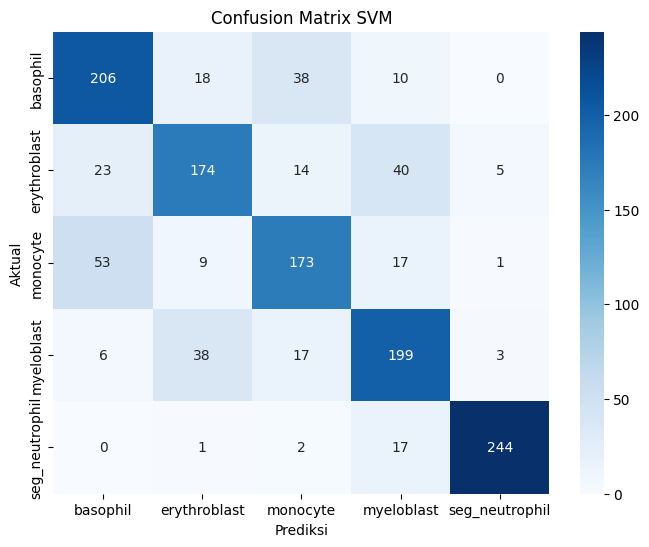

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred_svm
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=svm_model.classes_,
    yticklabels=svm_model.classes_
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix SVM")

plt.show()

#CNN

Persiapan CNN

In [ ]:
cnn_path = split_path

train_dir = os.path.join(
    cnn_path,
    "train"
)

val_dir = os.path.join(
    cnn_path,
    "val"
)

test_dir = os.path.join(
    cnn_path,
    "test"
)

Data Augmentation

In [ ]:
train_datagen = ImageDataGenerator(

    rescale=1./255,

    rotation_range=15,

    zoom_range=0.1,

    horizontal_flip=True,

    width_shift_range=0.1,

    height_shift_range=0.1
)

val_test_datagen = ImageDataGenerator(
    rescale=1./255
)

Train Generator

In [ ]:
train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    shuffle=True
)

Found 4303 images belonging to 5 classes.


Validation Generator

In [ ]:
val_generator = val_test_datagen.flow_from_directory(

    val_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    shuffle=False
)

Found 1298 images belonging to 5 classes.


Test Generator

In [ ]:
test_generator = val_test_datagen.flow_from_directory(

    test_dir,

    target_size=(224,224),

    batch_size=32,

    class_mode="categorical",

    shuffle=False
)

Found 1308 images belonging to 5 classes.


Arsitektur CNN

In [ ]:
model = Sequential()

model.add(
    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(224,224,3)
    )
)

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))


model.add(
    Conv2D(
        64,
        (3,3),
        activation="relu"
    )
)

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))


model.add(
    Conv2D(
        128,
        (3,3),
        activation="relu"
    )
)

model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))


model.add(GlobalAveragePooling2D())

model.add(
    Dense(
        128,
        activation="relu"
    )
)

model.add(
    Dropout(
        0.5
    )
)

model.add(
    Dense(
        5,
        activation="softmax"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [ ]:
model.compile(

    optimizer="adam",

    loss="categorical_crossentropy",

    metrics=["accuracy"]
)

Summary

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,301 (434.77 KB)

 Trainable params: 110,853 (433.02 KB)

 Non-trainable params: 448 (1.75 KB)

Callback

In [ ]:
early_stop = EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=2,

    verbose=1
)

Training CNN

In [ ]:
history = model.fit(

    train_generator,

    validation_data=val_generator,

    epochs=20,

    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 992s 7s/step - accuracy: 0.8831 - loss: 0.3599 - val_accuracy: 0.3790 - val_loss: 1.8810 - learning_rate: 0.0010
Epoch 2/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 70s 515ms/step - accuracy: 0.9463 - loss: 0.1806 - val_accuracy: 0.3713 - val_loss: 2.2280 - learning_rate: 0.0010
Epoch 3/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 68s 506ms/step - accuracy: 0.9624 - loss: 0.1246 - val_accuracy: 0.6194 - val_loss: 1.4277 - learning_rate: 0.0010
Epoch 4/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 73s 544ms/step - accuracy: 0.9637 - loss: 0.1147 - val_accuracy: 0.4730 - val_loss: 1.5882 - learning_rate: 0.0010
Epoch 5/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 72s 536ms/step - accuracy: 0.9728 - loss: 0.0879 - val_accuracy: 0.9430 - val_loss: 0.1599 - learning_rate: 0.0010
Epoch 6/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 72s 532ms/step - accuracy: 0.9737 - loss: 0.0786 - val_accuracy: 0.9538 - val_loss: 0.1376 - learning_rate: 0.0010
Epoch 7/20
135/135 ━━━━━━━━━━━━━━━━━━━━ 72s 536ms/step - accuracy: 0.971

Evaluasi

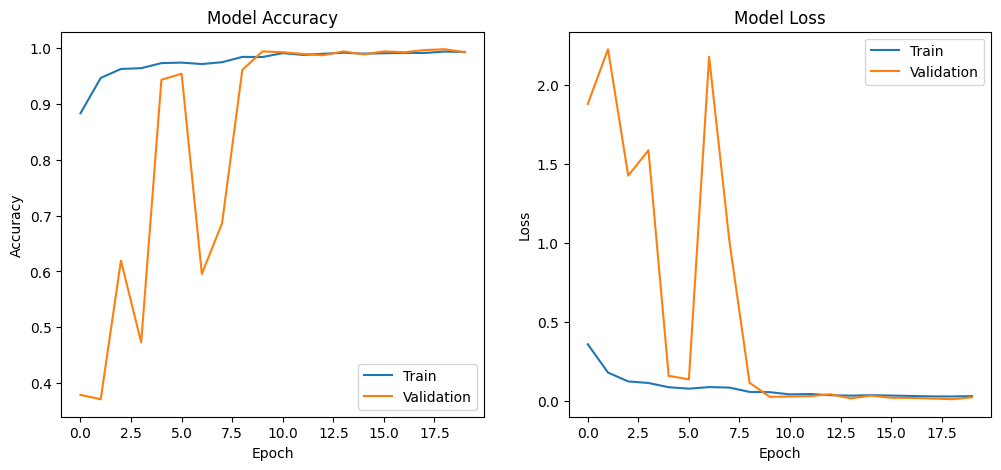

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train", "Validation"])

plt.show()

In [ ]:
loss, acc = model.evaluate(
    test_generator
)

print(f"Akurasi CNN : {acc:.4f}")

41/41 ━━━━━━━━━━━━━━━━━━━━ 7s 180ms/step - accuracy: 0.9946 - loss: 0.0118
Akurasi CNN : 0.9946


Prediksi CNN

In [ ]:
y_pred_prob = model.predict(
    test_generator
)

y_pred_cnn = np.argmax(
    y_pred_prob,
    axis=1
)

y_true = test_generator.classes

41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 234ms/step


Classification Report

In [ ]:
print(

    classification_report(

        y_true,

        y_pred_cnn,

        target_names=list(
            test_generator.class_indices.keys()
        )
    )
)

                precision    recall  f1-score   support

      basophil       1.00      1.00      1.00       272
  erythroblast       1.00      0.99      0.99       256
      monocyte       0.99      0.99      0.99       253
    myeloblast       0.99      1.00      0.99       263
seg_neutrophil       1.00      0.99      0.99       264

      accuracy                           0.99      1308
     macro avg       0.99      0.99      0.99      1308
  weighted avg       0.99      0.99      0.99      1308



Confusion Matrix

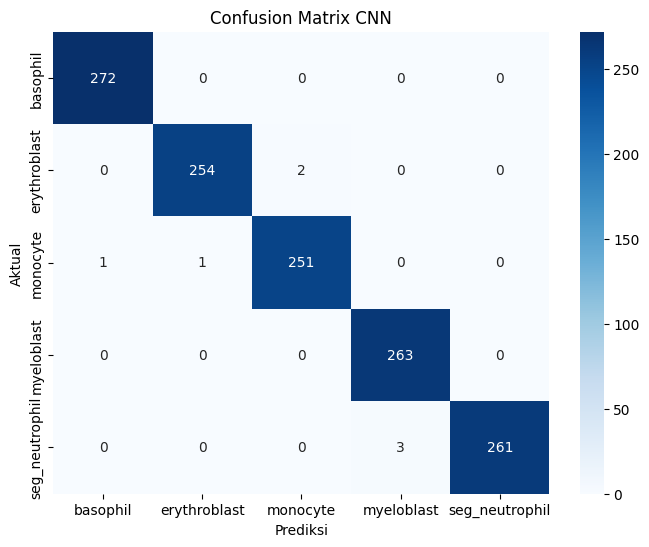

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred_cnn
)

plt.figure(figsize=(8,6))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=list(
        test_generator.class_indices.keys()
    ),

    yticklabels=list(
        test_generator.class_indices.keys()
    )
)

plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix CNN")

plt.show()

Hitung Metric

In [ ]:
cnn_precision = precision_score(

    y_true,

    y_pred_cnn,

    average="weighted"
)

cnn_recall = recall_score(

    y_true,

    y_pred_cnn,

    average="weighted"
)

cnn_f1 = f1_score(

    y_true,

    y_pred_cnn,

    average="weighted"
)

print(f"Akurasi CNN : {acc:.4f}")
print(f"Precision : {cnn_precision:.4f}")
print(f"Recall    : {cnn_recall:.4f}")
print(f"F1 Score  : {cnn_f1:.4f}")

Akurasi CNN : 0.9946
Precision : 0.9947
Recall    : 0.9946
F1 Score  : 0.9946


#Perbandingan Model

In [ ]:
hasil = pd.DataFrame({

    "Model":[
        "SVM",
        "CNN"
    ],

    "Accuracy":[
        svm_acc,
        acc
    ],

    "Precision":[
        svm_precision,
        cnn_precision
    ],

    "Recall":[
        svm_recall,
        cnn_recall
    ],

    "F1 Score":[
        svm_f1,
        cnn_f1
    ]
})

hasil

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM,0.761468,0.763824,0.761468,0.762051
1,CNN,0.994648,0.994674,0.994648,0.994647


In [ ]:
hasil.sort_values(
    by="Accuracy",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,CNN,0.994648,0.994674,0.994648,0.994647
0,SVM,0.761468,0.763824,0.761468,0.762051
